# Notebook 14 — Transferability: BPI Challenge 2017 (Loan Applications)

Demonstrates that the same process mining pipeline from Notebooks 01–13 transfers directly to a
different domain: consumer loan origination at a Dutch financial institution.

**Dataset:** BPI Challenge 2017 — 31,509 loan applications · 1.2M events · 26 activities  
**Target:** Did the application result in an accepted offer? (`O_Accepted` in trace = positive class, 54.7%)  
**Features:** `RequestedAmount`, `LoanGoal`, `ApplicationType`, prefix activity counts, elapsed time  

Lifecycle transitions are filtered to `complete` only to avoid counting start/schedule/suspend events.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import shap

ROOT = Path.cwd().parent
T    = ROOT / 'outputs' / 'tables'
OUT  = ROOT / 'outputs' / 'figures'
RANDOM_STATE = 42

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Ready')

Ready


## 1. Load log — filter to `complete` lifecycle events

In [2]:
from src.load_event_log import load_xes_log

log = load_xes_log(ROOT / 'data' / 'raw' / 'BPI Challenge 2017.xes', legacy=True)
print(f'Raw log: {len(log):,} cases  {sum(len(t) for t in log):,} events')

rows = []
for trace in log:
    cid    = str(trace.attributes.get('concept:name', ''))
    amount = trace.attributes.get('RequestedAmount', np.nan)
    goal   = str(trace.attributes.get('LoanGoal', ''))
    atype  = str(trace.attributes.get('ApplicationType', ''))
    for evt in trace:
        lc = str(evt.get('lifecycle:transition', '')).lower()
        if lc != 'complete':          # keep only completed activity executions
            continue
        rows.append({
            'case_id':   cid,
            'activity':  str(evt['concept:name']),
            'timestamp': evt['time:timestamp'],
            'resource':  str(evt.get('org:resource', '')),
            'origin':    str(evt.get('EventOrigin', '')),
            'amount':    amount,
            'goal':      goal,
            'app_type':  atype,
        })

df = pd.DataFrame(rows)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_localize(None)
df = df.sort_values(['case_id', 'timestamp']).reset_index(drop=True)

print(f'After lifecycle filter: {df["case_id"].nunique():,} cases  {len(df):,} events')
print(f'Activities: {df["activity"].nunique()}')
print(df.head(3))

parsing log, completed traces :: 100%|██████████| 31509/31509 [00:12<00:00, 2554.34it/s]


Raw log: 31,509 cases  1,202,267 events
After lifecycle filter: 31,509 cases  475,306 events
Activities: 24
                  case_id              activity               timestamp  \
0  Application_1000086665  A_Create Application 2016-08-03 15:57:21.673   
1  Application_1000086665           A_Submitted 2016-08-03 15:57:21.734   
2  Application_1000086665             A_Concept 2016-08-03 15:58:28.299   

  resource       origin  amount                    goal    app_type  
0   User_1  Application  5000.0  Other, see explanation  New credit  
1   User_1  Application  5000.0  Other, see explanation  New credit  
2   User_1  Application  5000.0  Other, see explanation  New credit  


## 2. Exploration

Cases:            31,509
Events (complete):475,306
Activities:       24
Duration median:  19.1d  p90: 35.0d
Events/case:      median=14  max=54
O_Accepted:       17,228 / 31,509 = 54.7%


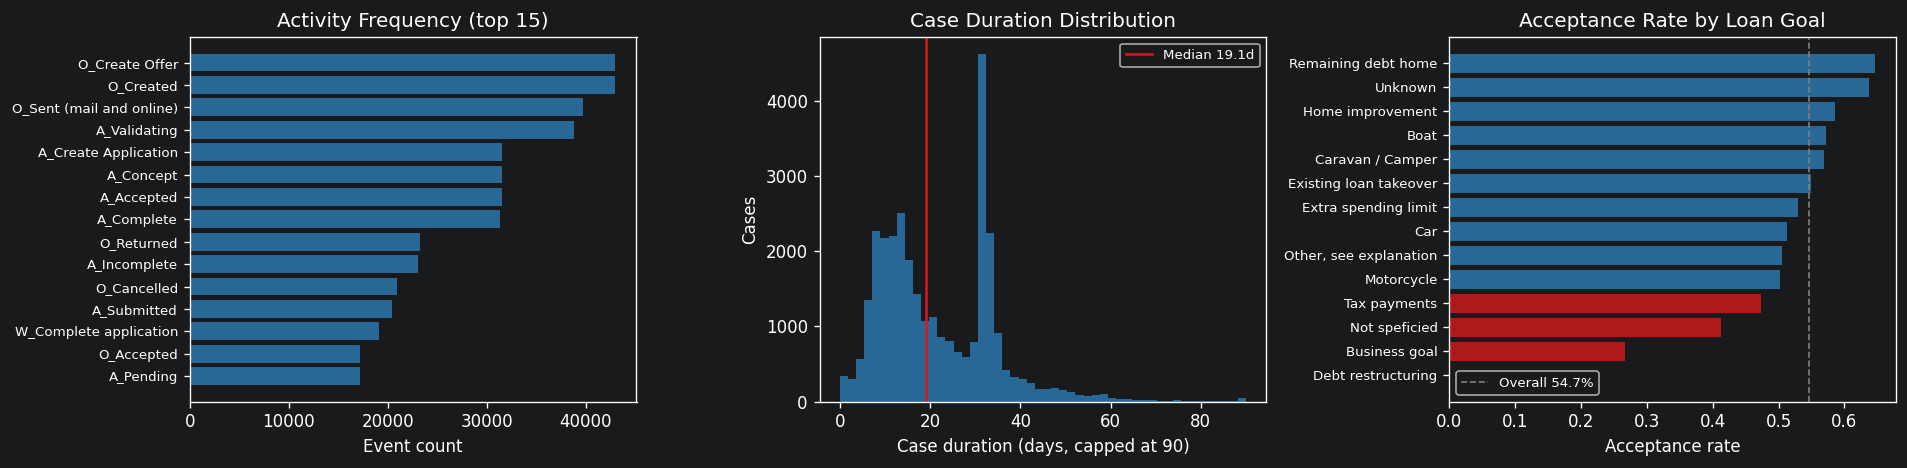

Saved transfer_exploration.png


In [3]:
case_grp   = df.groupby('case_id')
case_start = case_grp['timestamp'].min()
case_end   = case_grp['timestamp'].max()
case_len   = case_grp.size()

duration_days = (case_end - case_start).dt.total_seconds() / 86400

# Outcome: did the case ever contain O_Accepted?
accepted_cases = set(df[df['activity'] == 'O_Accepted']['case_id'].unique())
n_pos  = len(accepted_cases)
n_all  = df['case_id'].nunique()

print(f'Cases:            {n_all:,}')
print(f'Events (complete):{len(df):,}')
print(f'Activities:       {df["activity"].nunique()}')
print(f'Duration median:  {duration_days.median():.1f}d  p90: {duration_days.quantile(.9):.1f}d')
print(f'Events/case:      median={case_len.median():.0f}  max={case_len.max()}')
print(f'O_Accepted:       {n_pos:,} / {n_all:,} = {n_pos/n_all:.1%}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Activity frequency
act_freq = df['activity'].value_counts()
axes[0].barh(range(min(15, len(act_freq))),
             act_freq.head(15).values[::-1],
             color='#2c7bb6', alpha=0.8)
axes[0].set_yticks(range(min(15, len(act_freq))))
axes[0].set_yticklabels(act_freq.head(15).index[::-1], fontsize=8)
axes[0].set_xlabel('Event count')
axes[0].set_title('Activity Frequency (top 15)')

# Duration distribution
axes[1].hist(duration_days.clip(upper=90), bins=50, color='#2c7bb6', alpha=0.8, edgecolor='none')
axes[1].axvline(duration_days.median(), color='#d7191c', linewidth=1.5,
                label=f'Median {duration_days.median():.1f}d')
axes[1].set_xlabel('Case duration (days, capped at 90)')
axes[1].set_ylabel('Cases')
axes[1].set_title('Case Duration Distribution')
axes[1].legend(fontsize=8)

# Outcome by loan goal
goal_df = df.drop_duplicates('case_id')[['case_id','goal']].copy()
goal_df['accepted'] = goal_df['case_id'].isin(accepted_cases).astype(int)
goal_stats = (goal_df.groupby('goal')
              .agg(n=('accepted','count'), acc=('accepted','sum'))
              .assign(rate=lambda d: d['acc']/d['n'])
              .sort_values('rate', ascending=True))
axes[2].barh(range(len(goal_stats)), goal_stats['rate'],
             color=['#d7191c' if r < goal_stats['rate'].mean() else '#2c7bb6'
                    for r in goal_stats['rate']], alpha=0.8)
axes[2].axvline(n_pos/n_all, color='grey', linestyle='--', linewidth=1,
                label=f'Overall {n_pos/n_all:.1%}')
axes[2].set_yticks(range(len(goal_stats)))
axes[2].set_yticklabels([str(g)[:22] for g in goal_stats.index], fontsize=8)
axes[2].set_xlabel('Acceptance rate')
axes[2].set_title('Acceptance Rate by Loan Goal')
axes[2].legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUT / 'transfer_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved transfer_exploration.png')

## 3. Bottleneck analysis — mean waiting time by activity

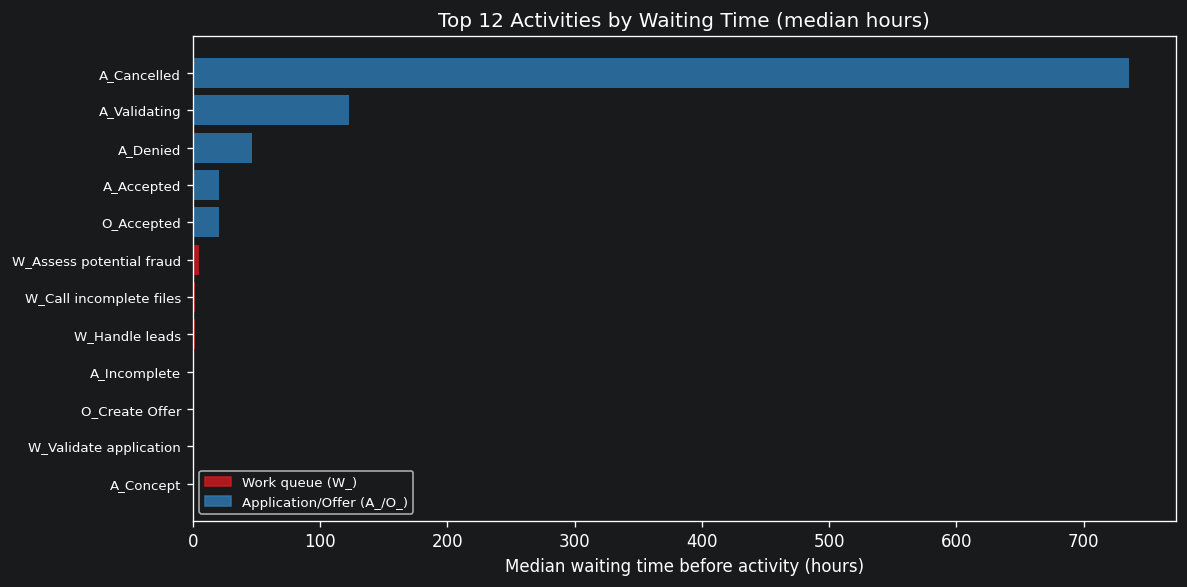

Saved transfer_bottleneck.png
                          median_wait   mean_wait      n
activity                                                
A_Cancelled                735.882583  612.501127  10431
A_Validating               122.890153  142.523623  38816
A_Denied                    46.397529   64.986027   3753
A_Accepted                  20.717942   34.026637  31509
O_Accepted                  20.710654   63.460725  17228
W_Assess potential fraud     4.986340   41.922875    282
W_Call incomplete files      1.739104   17.069608   2793
W_Handle leads               1.467742    6.316845   3493


In [4]:
# Compute inter-event waiting time (time from previous event to this one)
df2 = df.copy()
df2['prev_ts'] = df2.groupby('case_id')['timestamp'].shift(1)
df2['wait_h']  = (df2['timestamp'] - df2['prev_ts']).dt.total_seconds() / 3600

wait_stats = (df2.dropna(subset=['wait_h'])
              .groupby('activity')['wait_h']
              .agg(median_wait='median', mean_wait='mean', n='count')
              .sort_values('median_wait', ascending=False)
              .head(12))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d7191c' if 'W_' in a else '#2c7bb6' for a in wait_stats.index[::-1]]
ax.barh(range(len(wait_stats)), wait_stats['median_wait'].values[::-1],
        color=colors, alpha=0.8)
ax.set_yticks(range(len(wait_stats)))
ax.set_yticklabels([str(a)[:30] for a in wait_stats.index[::-1]], fontsize=8)
ax.set_xlabel('Median waiting time before activity (hours)')
ax.set_title('Top 12 Activities by Waiting Time (median hours)')
legend_els = [
    mpatches.Patch(color='#d7191c', alpha=0.8, label='Work queue (W_)'),
    mpatches.Patch(color='#2c7bb6', alpha=0.8, label='Application/Offer (A_/O_)'),
]
ax.legend(handles=legend_els, fontsize=8)
plt.tight_layout()
fig.savefig(OUT / 'transfer_bottleneck.png', dpi=150, bbox_inches='tight')
plt.show()

wait_stats.to_csv(T / 'transfer_wait_by_activity.csv')
print('Saved transfer_bottleneck.png')
print(wait_stats.head(8).to_string())

## 4. Feature engineering — prefix dataset

In [5]:
# Encode categoricals once
le_goal  = LabelEncoder()
le_atype = LabelEncoder()
case_meta = (df.drop_duplicates('case_id')
               .set_index('case_id')[['amount','goal','app_type']])
case_meta['goal_enc']  = le_goal.fit_transform(case_meta['goal'].fillna(''))
case_meta['atype_enc'] = le_atype.fit_transform(case_meta['app_type'].fillna(''))

# Pre-compute case outcome and total duration
outcome_s  = df['case_id'].isin(accepted_cases).groupby(df['case_id']).first()
total_dur  = (case_end - case_start).dt.total_seconds() / 86400

# Activity families
A_ACTS = sorted(df[df['activity'].str.startswith('A_')]['activity'].unique())
O_ACTS = sorted(df[df['activity'].str.startswith('O_')]['activity'].unique())
W_ACTS = sorted(df[df['activity'].str.startswith('W_')]['activity'].unique())
print(f'A_ activities ({len(A_ACTS)}): {A_ACTS}')
print(f'O_ activities ({len(O_ACTS)}): {O_ACTS}')
print(f'W_ activities ({len(W_ACTS)}): {W_ACTS}')

def make_prefix_features(df, case_meta, k):
    rows = []
    for cid, grp in df.groupby('case_id'):
        if len(grp) < k:
            continue
        prefix    = grp.head(k)
        t0        = prefix['timestamp'].iloc[0]
        t_k       = prefix['timestamp'].iloc[-1]
        elapsed   = (t_k - t0).total_seconds() / 86400
        acts_seen = prefix['activity'].tolist()

        meta = case_meta.loc[cid] if cid in case_meta.index else {}
        feats = {
            'case_id':      cid,
            'elapsed_days': elapsed,
            'n_events':     k,
            'amount':       meta.get('amount', np.nan) if hasattr(meta, 'get') else meta['amount'],
            'goal_enc':     meta.get('goal_enc', 0) if hasattr(meta, 'get') else meta['goal_enc'],
            'atype_enc':    meta.get('atype_enc', 0) if hasattr(meta, 'get') else meta['atype_enc'],
            'n_A':          sum(1 for a in acts_seen if a.startswith('A_')),
            'n_O':          sum(1 for a in acts_seen if a.startswith('O_')),
            'n_W':          sum(1 for a in acts_seen if a.startswith('W_')),
            'n_cancelled':  sum(1 for a in acts_seen if 'Cancelled' in a or 'Refused' in a or 'Denied' in a),
            'n_incomplete': sum(1 for a in acts_seen if 'Incomplete' in a or 'incomplete' in a),
            'has_offer':    int(any(a.startswith('O_') for a in acts_seen)),
            'has_accepted': int('O_Accepted' in acts_seen),
        }
        # Per-activity counts
        for a in A_ACTS + O_ACTS:
            feats[f'cnt_{a}'] = acts_seen.count(a)

        feats['label']         = int(cid in accepted_cases)
        feats['remaining_days'] = max(0, total_dur.get(cid, np.nan) - elapsed)
        rows.append(feats)
    return pd.DataFrame(rows)

# Quick test at k=5
sample = make_prefix_features(df, case_meta, k=5)
print(f'\nPrefix dataset at k=5: {len(sample):,} rows  {sample.shape[1]} features')
print(f'Positive rate at k=5: {sample["label"].mean():.1%}')

A_ activities (10): ['A_Accepted', 'A_Cancelled', 'A_Complete', 'A_Concept', 'A_Create Application', 'A_Denied', 'A_Incomplete', 'A_Pending', 'A_Submitted', 'A_Validating']
O_ activities (8): ['O_Accepted', 'O_Cancelled', 'O_Create Offer', 'O_Created', 'O_Refused', 'O_Returned', 'O_Sent (mail and online)', 'O_Sent (online only)']
W_ activities (6): ['W_Assess potential fraud', 'W_Call after offers', 'W_Call incomplete files', 'W_Complete application', 'W_Handle leads', 'W_Validate application']

Prefix dataset at k=5: 31,509 rows  33 features
Positive rate at k=5: 54.7%


## 5. Early warning model — AUC vs prefix length k

**Leakage audit:** `cnt_O_Accepted` is excluded from features — `O_Accepted` is the label event itself.
If it appears in a prefix it trivially reveals the outcome, the same pattern as `elapsed_days` in BPIC 2020 (Notebook 10).
All other O_ activity counts (`O_Create Offer`, `O_Sent`, `O_Cancelled`, `O_Returned`) are retained as legitimate process signals.

In [6]:
K_VALUES = [1, 2, 3, 5, 8, 10, 12, 15, 20]
cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Leakage note: cnt_O_Accepted is excluded because O_Accepted IS the label event.
# If it appears in the prefix the outcome is trivially known — same leakage pattern
# as elapsed_days in BPIC 2020 (corrected in Notebook 10).
LEAKY_COLS = {'case_id', 'label', 'remaining_days', 'has_accepted', 'cnt_O_Accepted'}

results = []

for k in K_VALUES:
    pfx = make_prefix_features(df, case_meta, k=k)
    if len(pfx) < 100:
        continue

    fcols = [c for c in pfx.columns if c not in LEAKY_COLS]
    X_k   = SimpleImputer(strategy='median', keep_empty_features=True).fit_transform(
                pfx[fcols])
    y_k   = pfx['label'].values

    model = xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_k==0).sum()/(y_k==1).sum(),
        random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss')

    auc_scores = cross_val_score(model, X_k, y_k, cv=cv, scoring='roc_auc')
    model.fit(X_k, y_k)

    results.append({
        'k': k, 'n': len(pfx),
        'auc_mean': auc_scores.mean(),
        'auc_std':  auc_scores.std(),
        'pos_rate': y_k.mean(),
    })
    print(f'k={k:2d}  n={len(pfx):,}  AUC={auc_scores.mean():.3f} ± {auc_scores.std():.3f}')

    if k == 8:
        feat_cols_k8 = fcols
        X_k8         = X_k
        y_k8         = y_k
        model_k8     = model

res_df = pd.DataFrame(results)
print(f'\nBest AUC: {res_df["auc_mean"].max():.3f} at k={res_df.loc[res_df["auc_mean"].idxmax(),"k"]}')

k= 1  n=31,509  AUC=0.607 ± 0.003
k= 2  n=31,509  AUC=0.613 ± 0.007
k= 3  n=31,509  AUC=0.621 ± 0.004
k= 5  n=31,509  AUC=0.621 ± 0.004
k= 8  n=31,491  AUC=0.647 ± 0.005
k=10  n=31,059  AUC=0.851 ± 0.005
k=12  n=24,200  AUC=0.882 ± 0.004
k=15  n=14,596  AUC=0.925 ± 0.004
k=20  n=4,568  AUC=0.931 ± 0.010

Best AUC: 0.931 at k=20


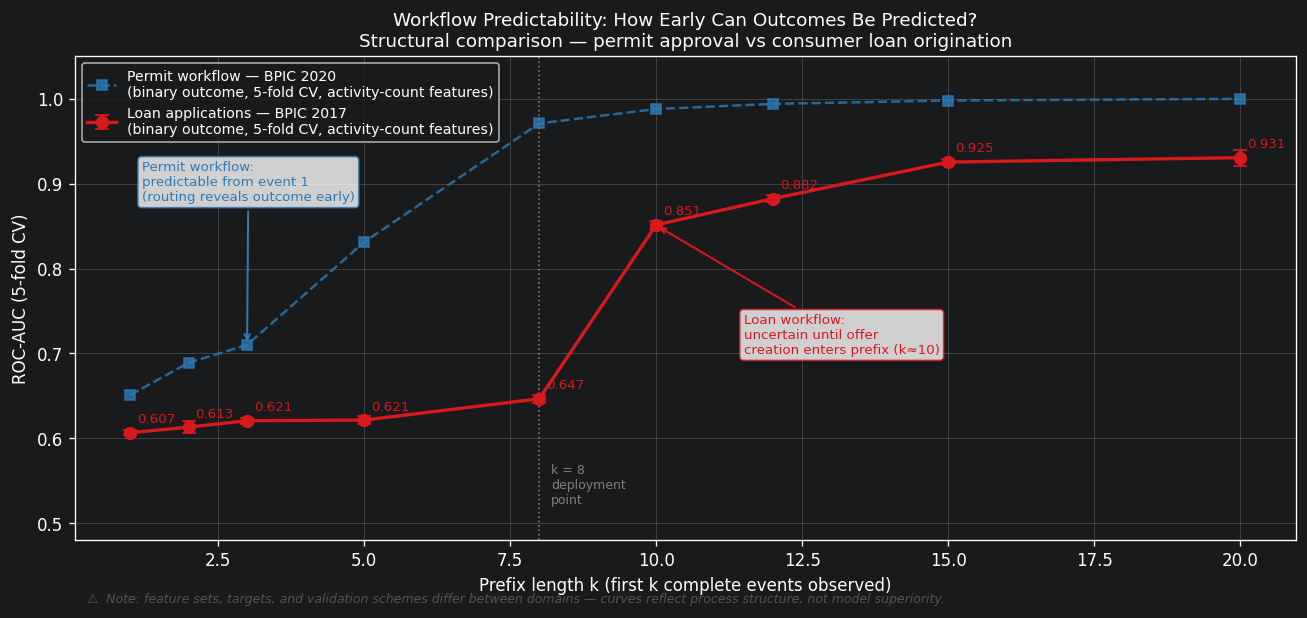

Saved transfer_auc_curve.png


In [7]:
# Comparison values from BPIC 2020 (Notebook 07)
bpic2020_k   = [1, 2, 3, 5, 8, 10, 12, 15, 20]
bpic2020_auc = [0.651, 0.689, 0.710, 0.831, 0.971, 0.988, 0.994, 0.998, 1.000]

fig, ax = plt.subplots(figsize=(11, 5.5))

# BPIC 2017 — loan applications
ax.errorbar(res_df['k'], res_df['auc_mean'], yerr=res_df['auc_std'],
            fmt='o-', color='#d7191c', linewidth=2, markersize=7, capsize=4,
            label='Loan applications — BPIC 2017\n(binary outcome, 5-fold CV, activity-count features)')
for _, r in res_df.iterrows():
    ax.annotate(f"{r['auc_mean']:.3f}",
                xy=(r['k'], r['auc_mean']),
                xytext=(4, 6), textcoords='offset points', fontsize=8, color='#d7191c')

# BPIC 2020 — permit workflow
ax.plot(bpic2020_k, bpic2020_auc, 's--', color='#2c7bb6', linewidth=1.5,
        markersize=6, alpha=0.8,
        label='Permit workflow — BPIC 2020\n(binary outcome, 5-fold CV, activity-count features)')

# Annotations
ax.axvline(8, color='grey', linestyle=':', linewidth=1)
ax.text(8.2, 0.52, 'k = 8\ndeployment\npoint', fontsize=7.5, color='grey', va='bottom')

ax.annotate('Permit workflow:\npredictable from event 1\n(routing reveals outcome early)',
            xy=(3, 0.710), xytext=(1.2, 0.88),
            arrowprops=dict(arrowstyle='->', color='#2c7bb6', lw=1.2),
            fontsize=8, color='#2c7bb6',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#2c7bb6', alpha=0.8))

ax.annotate('Loan workflow:\nuncertain until offer\ncreation enters prefix (k≈10)',
            xy=(10, 0.851), xytext=(11.5, 0.70),
            arrowprops=dict(arrowstyle='->', color='#d7191c', lw=1.2),
            fontsize=8, color='#d7191c',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#d7191c', alpha=0.8))

# Disclaimer — feature sets, targets, and validation schemes differ
ax.text(0.01, -0.13,
        '⚠  Note: feature sets, targets, and validation schemes differ between domains — '
        'curves reflect process structure, not model superiority.',
        transform=ax.transAxes, fontsize=7.5, color='#555555', style='italic')

ax.set_xlabel('Prefix length k (first k complete events observed)')
ax.set_ylabel('ROC-AUC (5-fold CV)')
ax.set_title('Workflow Predictability: How Early Can Outcomes Be Predicted?\n'
             'Structural comparison — permit approval vs consumer loan origination',
             fontsize=11)
ax.set_ylim(0.48, 1.05)
ax.legend(fontsize=8.5, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(OUT / 'transfer_auc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

res_df.to_csv(T / 'transfer_auc_by_k.csv', index=False)
print('Saved transfer_auc_curve.png')

## 6. SHAP feature importance at k=8

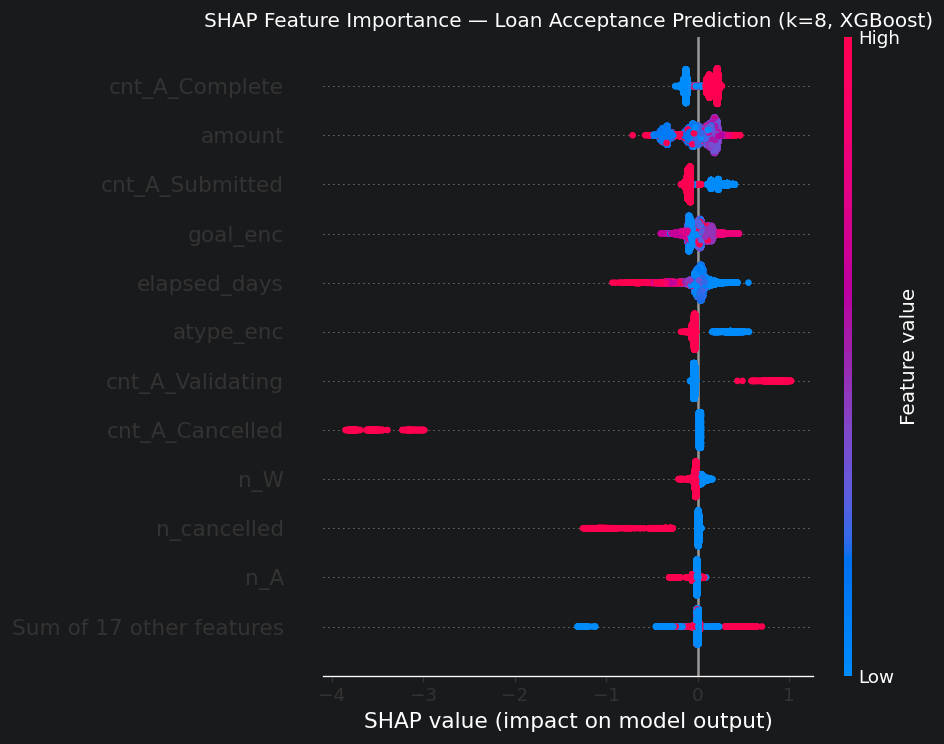

Saved transfer_shap.png


In [8]:
X_k8_df   = pd.DataFrame(X_k8, columns=feat_cols_k8)
explainer  = shap.TreeExplainer(model_k8)
shap_vals  = explainer(X_k8_df)

fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.beeswarm(shap_vals, max_display=12, show=False)
ax.set_title('SHAP Feature Importance — Loan Acceptance Prediction (k=8, XGBoost)')
plt.tight_layout()
fig.savefig(OUT / 'transfer_shap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved transfer_shap.png')

## 7. Remaining time prediction

Remaining time (k=8) — MAE: 9.6d  R²: 0.119  P10-P90 coverage: 79.0%


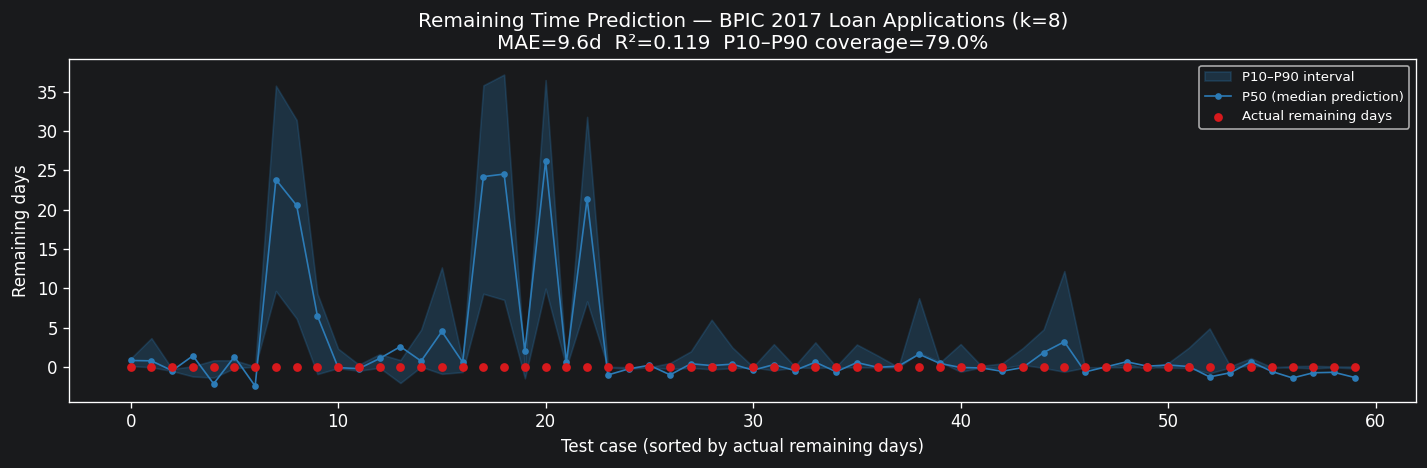

Saved transfer_remaining_time.png


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

pfx8 = make_prefix_features(df, case_meta, k=8)
pfx8 = pfx8[pfx8['remaining_days'] >= 0].dropna(subset=['remaining_days'])

reg_drop = ['case_id', 'label', 'remaining_days', 'has_accepted']
rfcols   = [c for c in pfx8.columns if c not in reg_drop]

imp_r = SimpleImputer(strategy='median', keep_empty_features=True)
Xr    = imp_r.fit_transform(pfx8[rfcols])
yr    = pfx8['remaining_days'].values

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    Xr, yr, test_size=0.2, random_state=RANDOM_STATE)

# Point estimate
reg_point = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8,
                               random_state=RANDOM_STATE, n_jobs=-1)
reg_point.fit(Xr_tr, yr_tr)
pred_p50 = reg_point.predict(Xr_te)

# Quantile models
preds_q = {}
for q, alpha in [(0.1, 0.1), (0.9, 0.9)]:
    m = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                          objective='reg:quantileerror', quantile_alpha=alpha,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(Xr_tr, yr_tr)
    preds_q[q] = m.predict(Xr_te)

mae   = mean_absolute_error(yr_te, pred_p50)
r2    = r2_score(yr_te, pred_p50)
cov   = np.mean((yr_te >= preds_q[0.1]) & (yr_te <= preds_q[0.9]))

print(f'Remaining time (k=8) — MAE: {mae:.1f}d  R²: {r2:.3f}  P10-P90 coverage: {cov:.1%}')

# Plot first 60 test cases sorted by actual remaining
idx60  = np.argsort(yr_te)[:60]
x60    = range(60)
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(x60, preds_q[0.1][idx60], preds_q[0.9][idx60],
                alpha=0.25, color='#2c7bb6', label='P10–P90 interval')
ax.plot(x60, pred_p50[idx60], 'o-', color='#2c7bb6', markersize=3,
        linewidth=1, label='P50 (median prediction)')
ax.scatter(x60, yr_te[idx60], color='#d7191c', s=18, zorder=5,
           label='Actual remaining days')
ax.set_xlabel('Test case (sorted by actual remaining days)')
ax.set_ylabel('Remaining days')
ax.set_title(f'Remaining Time Prediction — BPIC 2017 Loan Applications (k=8)\n'
             f'MAE={mae:.1f}d  R²={r2:.3f}  P10–P90 coverage={cov:.1%}')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(OUT / 'transfer_remaining_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved transfer_remaining_time.png')

## 8. Cross-domain comparison

**Framing note:** The two curves reflect *process structure*, not model quality. Feature sets, targets, and validation schemes differ between domains, so interpreting one curve as superior to the other would be misleading. The meaningful observation is behavioural: **workflow predictability varies substantially across domains**, and the shape of the AUC curve reveals *when* in the process the outcome signal concentrates.

- Permit workflow: signal rises smoothly from event 1 — routing decisions made early carry strong predictive information throughout.  
- Loan workflow: AUC is flat at 0.60–0.65 for k=1–8, then jumps sharply at k=10 when offer-creation events enter the prefix. Outcome uncertainty is irreducible until the credit decision stage.

In [10]:
k8_row = res_df[res_df['k'] == 8].iloc[0]

comparison = pd.DataFrame([
    {
        'Dataset':           'BPIC 2020 — Travel permit (Notebooks 01-13)',
        'Domain':            'Public sector / HR',
        'Cases':             '7,065',
        'Events':            '86,581',
        'Activities':        '51',
        'Median duration':   '72.4d',
        'Early warning AUC (k=8)': '0.810',
        'Remaining time MAE':'12.4d',
        'Target':            'Late completion (>90d)',
    },
    {
        'Dataset':           'BPIC 2017 — Loan application (Notebook 14)',
        'Domain':            'Financial services',
        'Cases':             '31,509',
        'Events':            f'{len(df):,}',
        'Activities':        str(df['activity'].nunique()),
        'Median duration':   f'{duration_days.median():.1f}d',
        'Early warning AUC (k=8)': f"{k8_row['auc_mean']:.3f}",
        'Remaining time MAE': f'{mae:.1f}d',
        'Target':            'Offer accepted (O_Accepted)',
    },
])

comparison.set_index('Dataset', inplace=True)
print(comparison.T.to_string())
comparison.to_csv(T / 'transfer_comparison.csv')
print('\nSaved transfer_comparison.csv')

Dataset                 BPIC 2020 — Travel permit (Notebooks 01-13) BPIC 2017 — Loan application (Notebook 14)
Domain                                           Public sector / HR                         Financial services
Cases                                                         7,065                                     31,509
Events                                                       86,581                                    475,306
Activities                                                       51                                         24
Median duration                                               72.4d                                      19.1d
Early warning AUC (k=8)                                       0.810                                      0.647
Remaining time MAE                                            12.4d                                       9.6d
Target                                       Late completion (>90d)                Offer accepted (O_Accepted)



In [11]:
summary = pd.DataFrame([{
    'n_cases':           df['case_id'].nunique(),
    'n_events_complete': len(df),
    'n_activities':      df['activity'].nunique(),
    'duration_median_d': round(duration_days.median(), 1),
    'outcome_pos_rate':  round(n_pos / n_all, 3),
    'auc_k1':            round(res_df[res_df['k']==1]['auc_mean'].values[0], 3) if 1 in res_df['k'].values else None,
    'auc_k8':            round(k8_row['auc_mean'], 3),
    'auc_best':          round(res_df['auc_mean'].max(), 3),
    'remaining_time_mae': round(mae, 1),
    'remaining_time_r2':  round(r2, 3),
    'p10_p90_coverage':   round(cov, 3),
}])
summary.to_csv(T / 'transfer_summary.csv', index=False)
print('Summary:')
print(summary.T.to_string(header=False))

Summary:
n_cases              31509.000
n_events_complete   475306.000
n_activities            24.000
duration_median_d       19.100
outcome_pos_rate         0.547
auc_k1                   0.607
auc_k8                   0.647
auc_best                 0.931
remaining_time_mae       9.600
remaining_time_r2        0.119
p10_p90_coverage         0.790
